In [24]:
import time
import copy
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from collections import Counter
from PIL import Image
from tqdm import tqdm

*Setup*

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

raw_dataset = r"C:\Users\Sina_Si1\Desktop\Project Code\Phase 2\PlantVillage"  # original dataset
balanced_dataset = r"C:\Users\Sina_Si1\Desktop\Project Code\Phase 2\PV_Balanced"  # after augmentation
split_output = r"C:\Users\Sina_Si1\Desktop\Project Code\Phase 2\PV_Split"  # train/val/test split

Using device: cuda


*Count Class Samples*

Original class distribution:


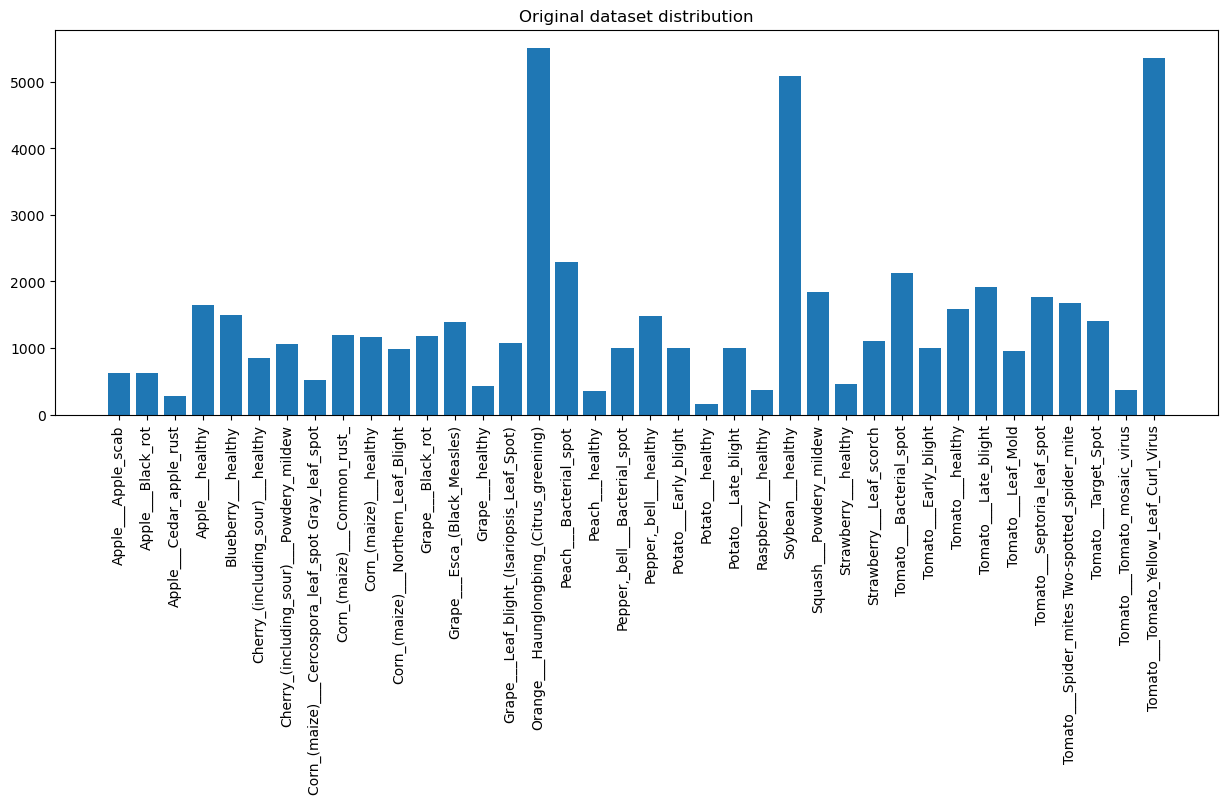

In [5]:
def plot_class_distribution(dataset_path, title):
    class_counts = {cls: len(os.listdir(os.path.join(dataset_path, cls)))
                    for cls in os.listdir(dataset_path)}
    plt.figure(figsize=(15, 5))
    plt.bar(class_counts.keys(), class_counts.values())
    plt.xticks(rotation=90)
    plt.title(title)
    plt.show()
    return class_counts

print("Original class distribution:")
orig_counts = plot_class_distribution(raw_dataset, "Original dataset distribution")

*Augmentation*

Balanced class distribution:


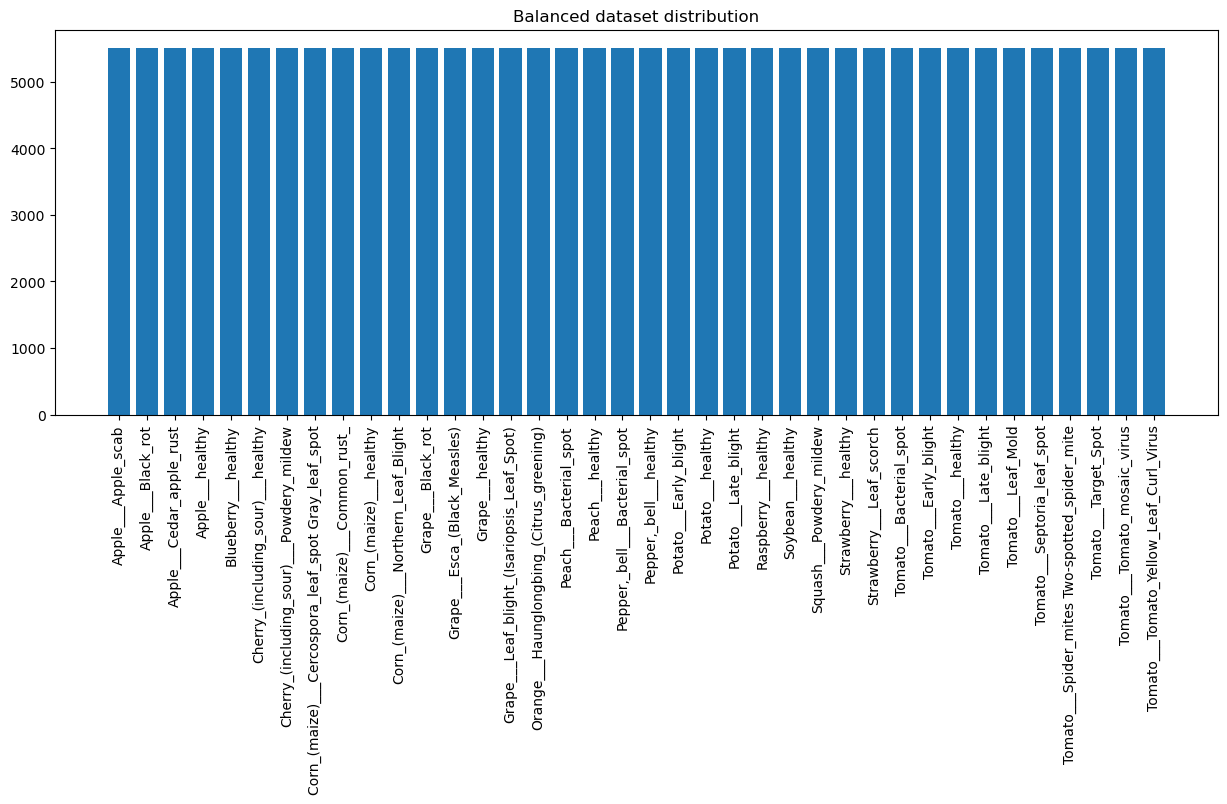

In [6]:
print("Balanced class distribution:")
balanced_counts = plot_class_distribution(balanced_dataset, "Balanced dataset distribution")

Balanced class distribution:


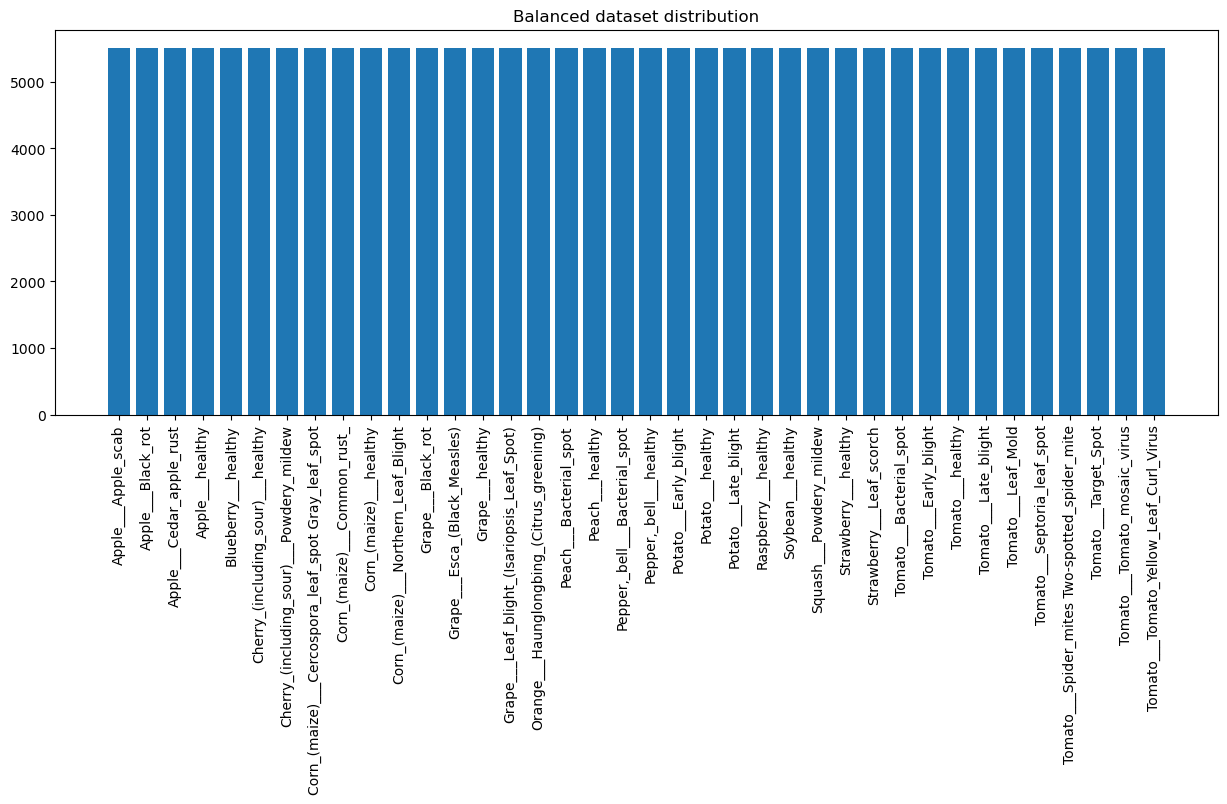

In [14]:
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.Resize((224, 224))
])

os.makedirs(balanced_dataset, exist_ok=True)
max_count = max(orig_counts.values())

for cls, count in orig_counts.items():
    src_dir = os.path.join(raw_dataset, cls)
    dst_dir = os.path.join(balanced_dataset, cls)
    os.makedirs(dst_dir, exist_ok=True)

    # Copy original
    for img in os.listdir(src_dir):
        shutil.copy(os.path.join(src_dir, img), os.path.join(dst_dir, img))

    # Augment until balanced
    imgs = os.listdir(src_dir)
    idx = 0
    while len(os.listdir(dst_dir)) < max_count:
        img = Image.open(os.path.join(src_dir, imgs[idx % len(imgs)])).convert("RGB")
        img_aug = transform_aug(img)
        save_path = os.path.join(dst_dir, f"aug_{idx}.png")
        img_aug.save(save_path)
        idx += 1

print("Balanced class distribution:")
balanced_counts = plot_class_distribution(balanced_dataset, "Balanced dataset distribution")

*Split Dataset*

In [16]:
def split_dataset(input_dir, output_dir, split_ratio=(0.6, 0.2, 0.2)):
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir, exist_ok=True)

    classes = os.listdir(input_dir)
    for cls in classes:
        cls_dir = os.path.join(input_dir, cls)
        images = os.listdir(cls_dir)
        train, temp = train_test_split(images, test_size=1-split_ratio[0], random_state=42)
        val, test = train_test_split(temp, test_size=0.5, random_state=42)

        for split, files in zip(["train", "val", "test"], [train, val, test]):
            split_dir = os.path.join(output_dir, split, cls)
            os.makedirs(split_dir, exist_ok=True)
            for f in files:
                shutil.copy(os.path.join(cls_dir, f), os.path.join(split_dir, f))

split_dataset(balanced_dataset, split_output)

*Data Loaders*

In [7]:
train_dir = os.path.join(split_output, "train")
val_dir = os.path.join(split_output, "val")
test_dir = os.path.join(split_output, "test")

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
val_data = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_data = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print("Dataset ready with", len(train_data), "train,", len(val_data), "val,", len(test_data), "test samples.")

Dataset ready with 125552 train, 41838 val, 41876 test samples.


*Training Loop*

In [25]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=7):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    train_loss, val_loss = [], []
    train_acc, val_acc = [], []

    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}')
        print('-' * 20)

        for phase, loader in [('train', train_loader), ('val', val_loader)]:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            loop = tqdm(loader, desc=f"{phase} Epoch {epoch+1}/{epochs}", leave=False)

            for inputs, labels in loop:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                loop.set_postfix(loss=loss.item())

            epoch_loss = running_loss / len(loader.dataset)
            epoch_acc = running_corrects.double() / len(loader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                train_loss.append(epoch_loss)
                train_acc.append(epoch_acc.item())
            else:
                val_loss.append(epoch_loss)
                val_acc.append(epoch_acc.item())

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, {"train_loss": train_loss, "val_loss": val_loss,
                   "train_acc": train_acc, "val_acc": val_acc}

*Evaluation*

In [ ]:
def evaluate_model(model, test_loader, model_name):
    model.eval()
    preds, labels_list = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    print(f"Classification Report for {model_name}:")
    print(classification_report(labels_list, preds))

    cm = confusion_matrix(labels_list, preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=False, cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    return {
        "report": classification_report(labels_list, preds, output_dict=True),
        "confusion_matrix": cm
    }

**Run Models**

In [27]:
results = {}

Training ResNet50...
Epoch 1/7
--------------------


train Loss: 0.3532 Acc: 0.8860


val Loss: 0.1463 Acc: 0.9490

Epoch 2/7
--------------------


train Loss: 0.1298 Acc: 0.9566


val Loss: 0.1592 Acc: 0.9470

Epoch 3/7
--------------------


...

val Loss: 0.0557 Acc: 0.9807

Epoch 6/7
--------------------


train Loss: 0.0360 Acc: 0.9879


val Loss: 0.0624 Acc: 0.9813

Epoch 7/7
--------------------


train Loss: 0.0307 Acc: 0.9898


val Loss: 0.0345 Acc: 0.9886

Training complete in 144m 60s
Best val Acc: 0.9886
Classification Report for ResNet50:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1102
           1       1.00      0.99      1.00      1102
           2       1.00      1.00      1.00      1102
           3       0.98      1.00      0.99      1102
           4       1.00      1.00      1.00      1102
           5       0.99      1.00      1.00      1102
           6       1.00      1.00      1.00      1102
           7       0.94      0.98      0.96      1102
           8       0.99      1.00      0.99      1102
           9       0.98      0.93      0.96      1102
          10       1.00      1.00      1.00      1102
          11       1.00      1.00      1.00      1102
          12       1.00      1.00      1.00      1102
          13       1.00      1.00      1.00      1102
          14       1.00      1.00      1.00      1102
          15      

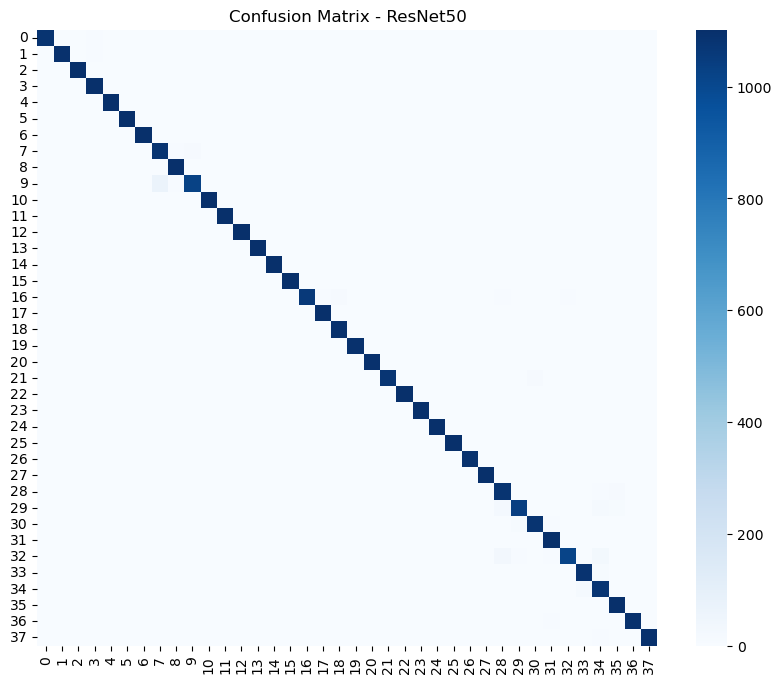

In [28]:
# ResNet50
print("Training ResNet50...")
model_resnet = models.resnet50(weights="IMAGENET1K_V1")
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, len(train_data.classes))
model_resnet = model_resnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_resnet.parameters(), lr=0.001)

model_resnet, hist_resnet = train_model(model_resnet, train_loader, val_loader, criterion, optimizer, epochs=7)
results["ResNet50"] = evaluate_model(model_resnet, test_loader, "ResNet50")

Training EfficientNetB0...


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Sina_Si1/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [06:11<00:00, 57.7kB/s]


Epoch 1/7
--------------------


train Loss: 0.1648 Acc: 0.9486


val Loss: 0.0656 Acc: 0.9784

Epoch 2/7
--------------------


...

val Loss: 0.0288 Acc: 0.9908

Epoch 6/7
--------------------


train Loss: 0.0293 Acc: 0.9902


val Loss: 0.0396 Acc: 0.9891

Epoch 7/7
--------------------


train Loss: 0.0269 Acc: 0.9911


val Loss: 0.0211 Acc: 0.9930

Training complete in 99m 35s
Best val Acc: 0.9930
Classification Report for EfficientNetB0:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1102
           1       1.00      1.00      1.00      1102
           2       1.00      1.00      1.00      1102
           3       1.00      0.99      0.99      1102
           4       1.00      1.00      1.00      1102
           5       1.00      1.00      1.00      1102
           6       1.00      1.00      1.00      1102
           7       0.98      0.97      0.98      1102
           8       1.00      1.00      1.00      1102
           9       0.97      0.98      0.98      1102
          10       1.00      1.00      1.00      1102
          11       0.98      1.00      0.99      1102
          12       1.00      0.98      0.99      1102
          13       0.99      1.00      1.00      1102
          14       1.00      1.00      1.00      1102
          15 

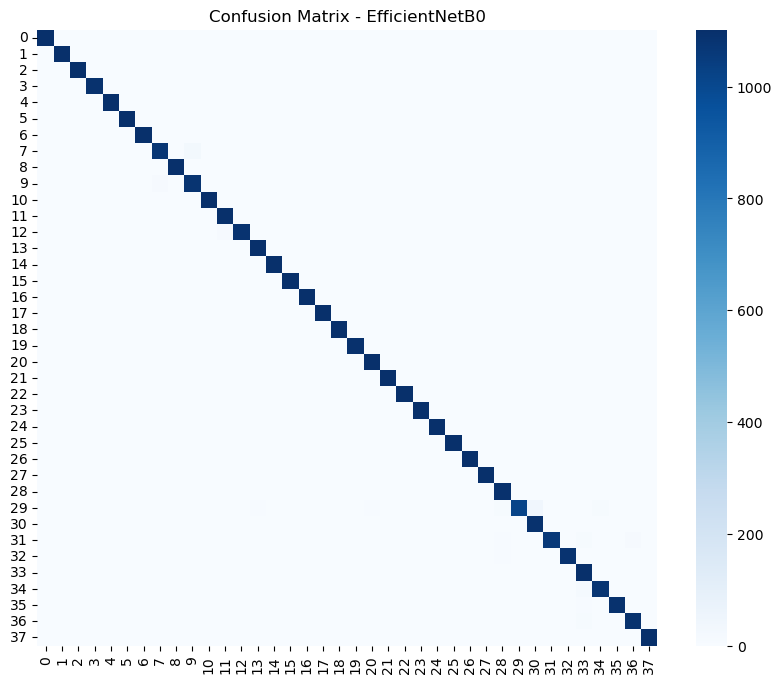

In [29]:
# EfficientNetB0
print("Training EfficientNetB0...")
model_eff = models.efficientnet_b0(weights="IMAGENET1K_V1")
model_eff.classifier[1] = nn.Linear(model_eff.classifier[1].in_features, len(train_data.classes))
model_eff = model_eff.to(device)

optimizer_eff = optim.Adam(model_eff.parameters(), lr=0.001)

model_eff, hist_eff = train_model(model_eff, train_loader, val_loader, criterion, optimizer_eff, epochs=7)
results["EfficientNetB0"] = evaluate_model(model_eff, test_loader, "EfficientNetB0")

Training MobileNetV2...
Epoch 1/7
--------------------


train Loss: 0.2655 Acc: 0.9138


val Loss: 0.1885 Acc: 0.9419

Epoch 2/7
--------------------


train Loss: 0.1325 Acc: 0.9571


val Loss: 0.1227 Acc: 0.9604

Epoch 3/7
--------------------


...

val Loss: 0.0633 Acc: 0.9789

Epoch 6/7
--------------------


train Loss: 0.0598 Acc: 0.9803


val Loss: 0.0527 Acc: 0.9823

Epoch 7/7
--------------------


train Loss: 0.0528 Acc: 0.9827


val Loss: 0.0334 Acc: 0.9892

Training complete in 86m 42s
Best val Acc: 0.9892
Classification Report for MobileNetV2:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1102
           1       1.00      1.00      1.00      1102
           2       1.00      1.00      1.00      1102
           3       1.00      1.00      1.00      1102
           4       1.00      1.00      1.00      1102
           5       0.99      1.00      1.00      1102
           6       1.00      0.99      1.00      1102
           7       0.93      0.98      0.96      1102
           8       1.00      1.00      1.00      1102
           9       0.98      0.93      0.95      1102
          10       1.00      1.00      1.00      1102
          11       0.99      1.00      0.99      1102
          12       1.00      0.99      0.99      1102
          13       1.00      1.00      1.00      1102
          14       1.00      0.99      1.00      1102
          15    

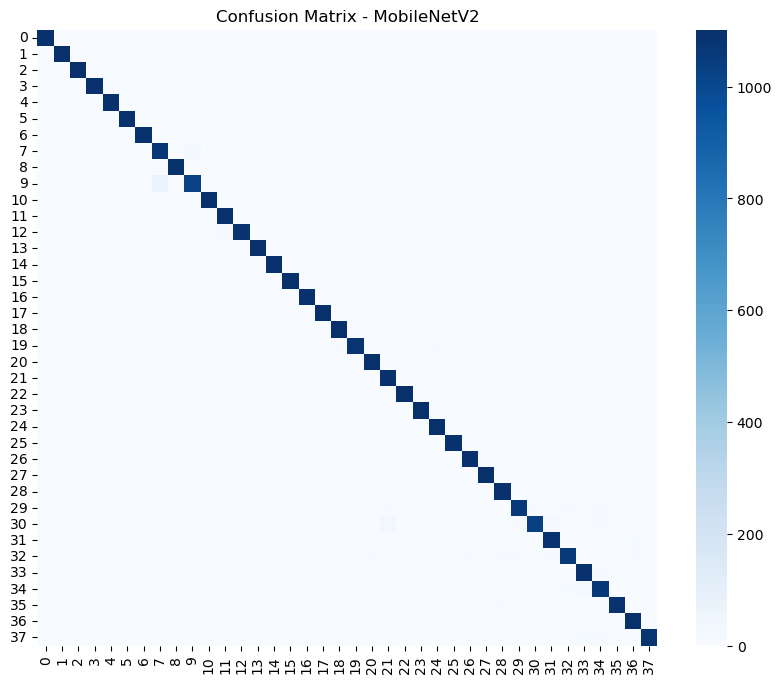

In [30]:
# MobileNetV2
print("Training MobileNetV2...")
model_mob = models.mobilenet_v2(weights="IMAGENET1K_V1")
model_mob.classifier[1] = nn.Linear(model_mob.classifier[1].in_features, len(train_data.classes))
model_mob = model_mob.to(device)

optimizer_mob = optim.Adam(model_mob.parameters(), lr=0.001)

model_mob, hist_mob = train_model(model_mob, train_loader, val_loader, criterion, optimizer_mob, epochs=7)
results["MobileNetV2"] = evaluate_model(model_mob, test_loader, "MobileNetV2")

*Compare Results*

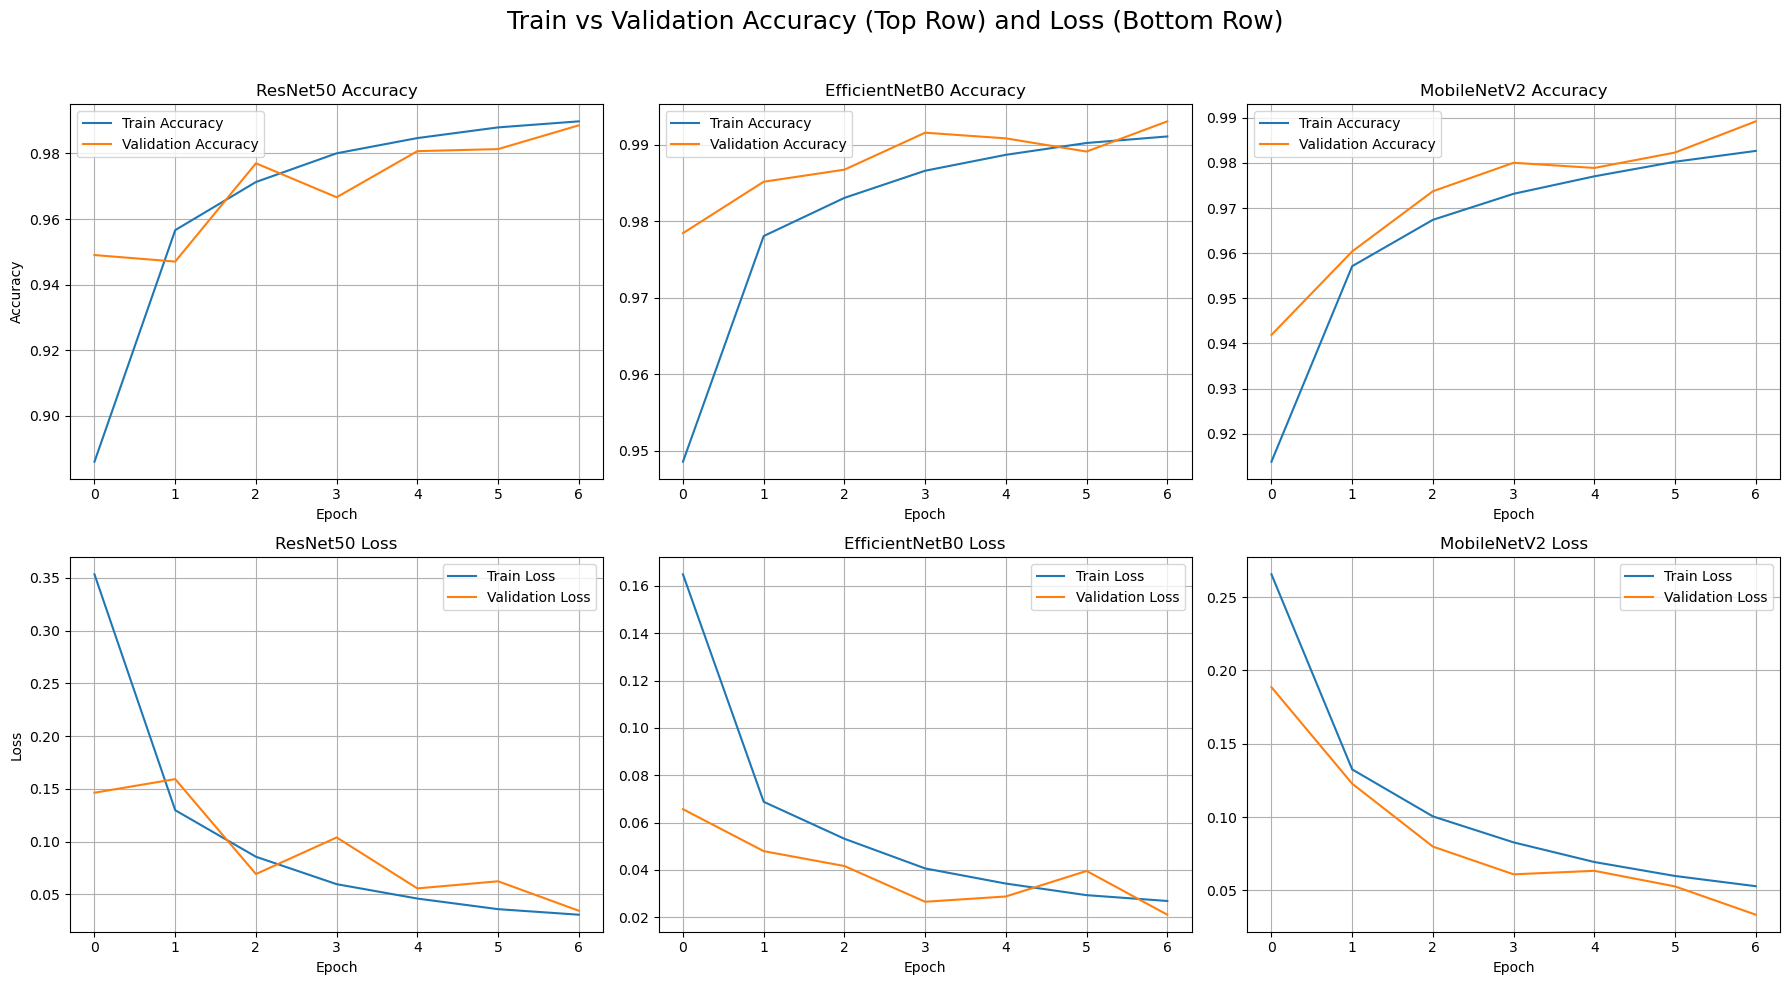

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))

# ========== Accuracy ==========
# ResNet50
axes[0,0].plot(hist_resnet["train_acc"], label="Train Accuracy")
axes[0,0].plot(hist_resnet["val_acc"], label="Validation Accuracy")
axes[0,0].set_title("ResNet50 Accuracy")
axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("Accuracy")
axes[0,0].legend()
axes[0,0].grid(True)

# EfficientNetB0
axes[0,1].plot(hist_eff["train_acc"], label="Train Accuracy")
axes[0,1].plot(hist_eff["val_acc"], label="Validation Accuracy")
axes[0,1].set_title("EfficientNetB0 Accuracy")
axes[0,1].set_xlabel("Epoch")
axes[0,1].legend()
axes[0,1].grid(True)

# MobileNetV2
axes[0,2].plot(hist_mob["train_acc"], label="Train Accuracy")
axes[0,2].plot(hist_mob["val_acc"], label="Validation Accuracy")
axes[0,2].set_title("MobileNetV2 Accuracy")
axes[0,2].set_xlabel("Epoch")
axes[0,2].legend()
axes[0,2].grid(True)

# ========== Loss ==========
# ResNet50
axes[1,0].plot(hist_resnet["train_loss"], label="Train Loss")
axes[1,0].plot(hist_resnet["val_loss"], label="Validation Loss")
axes[1,0].set_title("ResNet50 Loss")
axes[1,0].set_xlabel("Epoch")
axes[1,0].set_ylabel("Loss")
axes[1,0].legend()
axes[1,0].grid(True)

# EfficientNetB0
axes[1,1].plot(hist_eff["train_loss"], label="Train Loss")
axes[1,1].plot(hist_eff["val_loss"], label="Validation Loss")
axes[1,1].set_title("EfficientNetB0 Loss")
axes[1,1].set_xlabel("Epoch")
axes[1,1].legend()
axes[1,1].grid(True)

# MobileNetV2
axes[1,2].plot(hist_mob["train_loss"], label="Train Loss")
axes[1,2].plot(hist_mob["val_loss"], label="Validation Loss")
axes[1,2].set_title("MobileNetV2 Loss")
axes[1,2].set_xlabel("Epoch")
axes[1,2].legend()
axes[1,2].grid(True)

plt.suptitle("Train vs Validation Accuracy (Top Row) and Loss (Bottom Row)", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


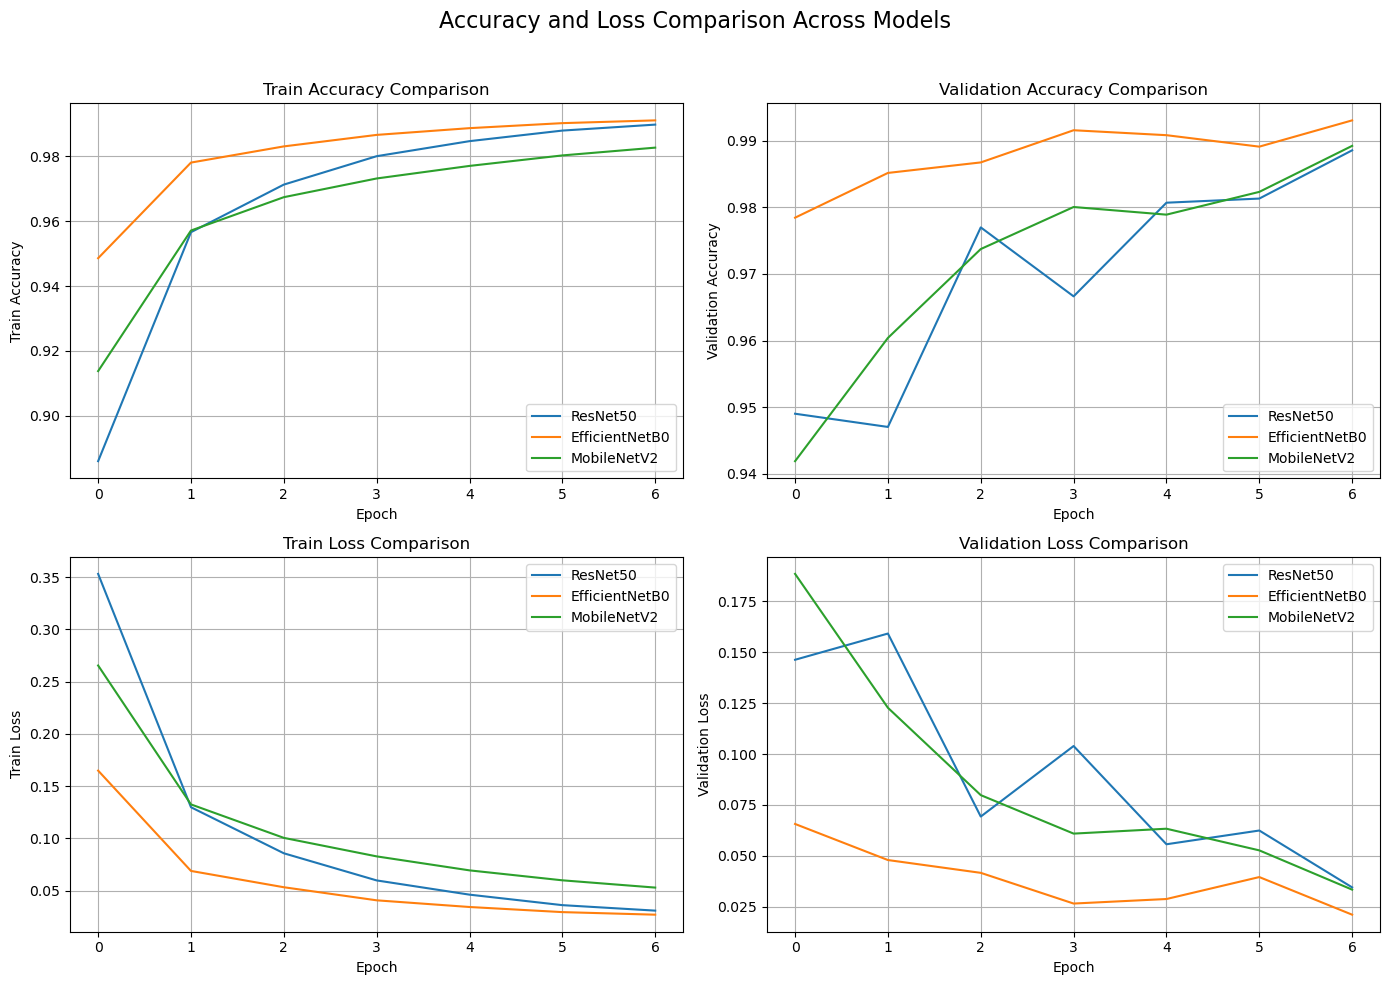

In [54]:
fig, axs = plt.subplots(2, 2, figsize=(14,10))

# ---------- Top-Left: Train Accuracy ----------
axs[0,0].plot(hist_resnet["train_acc"], label="ResNet50")
axs[0,0].plot(hist_eff["train_acc"], label="EfficientNetB0")
axs[0,0].plot(hist_mob["train_acc"], label="MobileNetV2")
axs[0,0].set_xlabel("Epoch")
axs[0,0].set_ylabel("Train Accuracy")
axs[0,0].set_title("Train Accuracy Comparison")
axs[0,0].legend()
axs[0,0].grid(True)

# ---------- Top-Right: Validation Accuracy ----------
axs[0,1].plot(hist_resnet["val_acc"], label="ResNet50")
axs[0,1].plot(hist_eff["val_acc"], label="EfficientNetB0")
axs[0,1].plot(hist_mob["val_acc"], label="MobileNetV2")
axs[0,1].set_xlabel("Epoch")
axs[0,1].set_ylabel("Validation Accuracy")
axs[0,1].set_title("Validation Accuracy Comparison")
axs[0,1].legend()
axs[0,1].grid(True)

# ---------- Bottom-Left: Train Loss ----------
axs[1,0].plot(hist_resnet["train_loss"], label="ResNet50")
axs[1,0].plot(hist_eff["train_loss"], label="EfficientNetB0")
axs[1,0].plot(hist_mob["train_loss"], label="MobileNetV2")
axs[1,0].set_xlabel("Epoch")
axs[1,0].set_ylabel("Train Loss")
axs[1,0].set_title("Train Loss Comparison")
axs[1,0].legend()
axs[1,0].grid(True)

# ---------- Bottom-Right: Validation Loss ----------
axs[1,1].plot(hist_resnet["val_loss"], label="ResNet50")
axs[1,1].plot(hist_eff["val_loss"], label="EfficientNetB0")
axs[1,1].plot(hist_mob["val_loss"], label="MobileNetV2")
axs[1,1].set_xlabel("Epoch")
axs[1,1].set_ylabel("Validation Loss")
axs[1,1].set_title("Validation Loss Comparison")
axs[1,1].legend()
axs[1,1].grid(True)

plt.suptitle("Accuracy and Loss Comparison Across Models", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
